# Political Alpha — Results Notebook

**DSCI 510 — Spring 2026 — University of Southern California**  
Run from the project root: `jupyter notebook results.ipynb`

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('src').resolve()))

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

from config import DATA_DIR, RESULTS_DIR, SECTORS, SECTOR_NAMES
print('Config loaded — sectors:', list(SECTORS.keys()))

Config loaded — sectors: ['defense', 'finance', 'energy', 'healthcare', 'tech']


## 1. Run Pipeline
Runs all stages from cached data in `data/`. No re-fetching.

In [2]:
import tagging, heat_signal, rq1_predictive, rq2_sensitivity, alpha_context

print('Tagging trades...')
tagging.main()
print('Building heat score...')
heat_signal.main()
print('Running RQ1...')
rq1_predictive.main()
print('Running RQ2...')
rq2_sensitivity.main()
print('Computing alpha...')
alpha_context.main()
print('Done.')

Tagging trades...
[tagging] wrote /Users/ananthdhananjay/Downloads/politicalalpha2/data/ptr_trades_tagged.csv rows=588 (17.0% of 3468)
[tagging] by sector:
sector
tech          230
healthcare    119
finance       113
energy        112
defense        14
Building heat score...
[signal] wrote /Users/ananthdhananjay/Downloads/politicalalpha2/data/heat_score.csv rows=745 non-null heat=98
Running RQ1...
[rq1] wrote rq1_inference.csv rows=20 sig@p<.05: 1 | sig@p<.10: 3
Running RQ2...
[rq2] wrote rq2_sensitivity.csv rows=45 full-sample sig@p<.05: 2/15
Computing alpha...
POLITICAL ALPHA - PORTFOLIO REPORT

Strategy: long top-2 heat, short bottom-2 heat.
Rebalance weekly. 1-week heat lag prevents look-ahead.

Portfolio statistics:
  n_weeks                152
  mean_weekly            0.0004
  std_weekly             0.0183
  ann_return             0.0216
  ann_vol                0.1317
  sharpe                 0.1622
  max_drawdown           -0.1586
  cumulative_return      0.0380

Factor regress

## 2. Load Results

In [3]:
rq1       = pd.read_csv(RESULTS_DIR / 'rq1_inference.csv')
rq2       = pd.read_csv(RESULTS_DIR / 'rq2_sensitivity.csv')
alpha     = pd.read_csv(RESULTS_DIR / 'alpha_summary.csv')
portfolio = pd.read_csv(RESULTS_DIR / 'portfolio_returns.csv', parse_dates=['Date'])
portfolio = portfolio.set_index('Date')
market    = pd.read_csv(DATA_DIR / 'market.csv', index_col=0, parse_dates=True)
heat_long = pd.read_csv(DATA_DIR / 'heat_score.csv', parse_dates=True)
heat_wide = heat_long.pivot_table(index=heat_long.index, columns='sector', values='heat')
heat_wide.index = pd.to_datetime(heat_wide.index)

print('RQ1:', rq1.shape, '| RQ2:', rq2.shape, '| Alpha:', alpha.shape)
print('Portfolio rows:', len(portfolio))
print('Heat wide shape:', heat_wide.shape)

RQ1: (20, 7) | RQ2: (45, 9) | Alpha: (2, 10)
Portfolio rows: 152
Heat wide shape: (98, 5)


## 3. Political Heat Score

Heat score shape: (128, 5)
Date range: 2023-03-17 00:00:00 to 2026-04-17 00:00:00


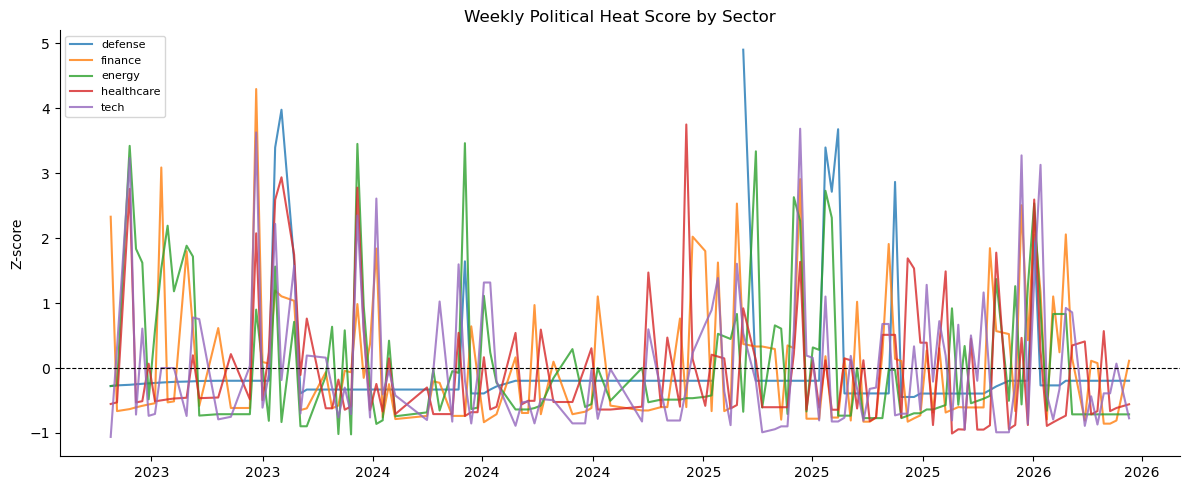

In [4]:
from config import SECTOR_NAMES, ZSCORE_WINDOW_WEEKS

tagged = pd.read_csv(DATA_DIR / 'ptr_trades_tagged.csv')
from config import SECTOR_NAMES, ZSCORE_WINDOW_WEEKS

tagged['transaction_date'] = pd.to_datetime(tagged['transaction_date'], errors='coerce')
tagged = tagged.dropna(subset=['transaction_date', 'sector'])

# Weekly counts per sector
weekly = tagged.groupby([
    pd.Grouper(key='transaction_date', freq='W-FRI'),
    'sector'
]).size().unstack(fill_value=0)

for s in SECTOR_NAMES:
    if s not in weekly.columns:
        weekly[s] = 0
weekly = weekly[SECTOR_NAMES]

# Rolling z-score
roll = weekly.rolling(ZSCORE_WINDOW_WEEKS, min_periods=13)
heat_wide = ((weekly - roll.mean()) / roll.std().replace(0, float('nan'))).dropna(how='all')

print('Heat score shape:', heat_wide.shape)
print('Date range:', heat_wide.index.min(), 'to', heat_wide.index.max())

# Plot
fig, ax = plt.subplots()
for sector in heat_wide.columns:
    ax.plot(heat_wide.index, heat_wide[sector], label=sector, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Weekly Political Heat Score by Sector')
ax.set_ylabel('Z-score')
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

### Top Senators by Trade Count
`(load_senate.py · fetch_senate_trades)`

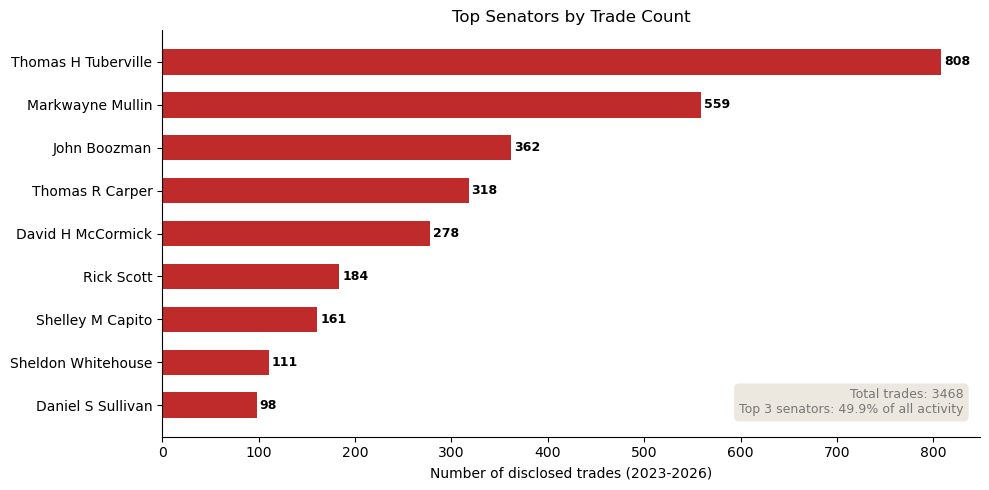

Total trades: 3468 | Senators reporting: 44


In [5]:
senate_file = DATA_DIR / 'ptr_trades.csv'
if senate_file.exists():
    raw_trades = pd.read_csv(senate_file)
    date_col = next((c for c in raw_trades.columns if 'date' in c.lower()), None)
    if date_col:
        raw_trades['date'] = pd.to_datetime(raw_trades[date_col], errors='coerce')
    sen_col = next((c for c in raw_trades.columns if 'senator' in c.lower() or 'filer' in c.lower()), raw_trades.columns[0])
    senator_counts = raw_trades.groupby(sen_col).size().sort_values(ascending=True)
    top_n = senator_counts.tail(9)
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(top_n.index, top_n.values, color='#BF2B2B', height=0.6)
    for bar, val in zip(bars, top_n.values):
        ax.text(val + 3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9, fontweight='bold')
    ax.set_xlabel('Number of disclosed trades (2023-2026)')
    ax.set_title('Top Senators by Trade Count')
    total = len(raw_trades)
    top3 = senator_counts.tail(3).sum()
    pct = round(100 * top3 / total, 1)
    stats_text = 'Total trades: ' + str(total) + '\nTop 3 senators: ' + str(pct) + '% of all activity'
    ax.text(0.98, 0.05, stats_text, transform=ax.transAxes, ha='right', va='bottom',
            fontsize=9, color='#777777',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#EDE8DF', edgecolor='none'))
    plt.tight_layout()
    plt.show()
    print('Total trades: ' + str(total) + ' | Senators reporting: ' + str(len(senator_counts)))
else:
    print('ptr_trades.csv not found - run main.py --fetch first')

### Net Dollar Flow by Sector
`(tagging.py · tag_trades)`

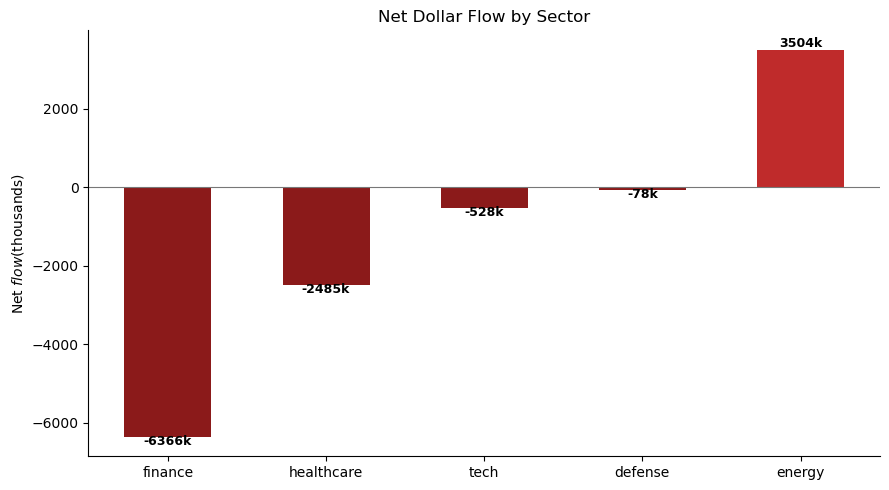


Buy share by sector:
    sector buy_pct  buys  sells
healthcare     38%    44     71
      tech     44%   101    129
    energy     48%    53     57
   finance     49%    55     58
   defense     57%     8      6


In [6]:
tagged_file = DATA_DIR / 'ptr_trades_tagged.csv'
if tagged_file.exists():
    tagged = pd.read_csv(tagged_file)
    date_col = next((c for c in tagged.columns if 'date' in c.lower()), None)
    if date_col:
        tagged['date'] = pd.to_datetime(tagged[date_col], errors='coerce')
    AMOUNT_MAP = {
        '$1,001 - $15,000': 8000, '$15,001 - $50,000': 32500,
        '$50,001 - $100,000': 75000, '$100,001 - $250,000': 175000,
        '$250,001 - $500,000': 375000, '$500,001 - $1,000,000': 750000,
        '$1,000,001 - $5,000,000': 3000000, 'Over $5,000,000': 5000000,
    }
    amount_col = next((c for c in tagged.columns if 'amount' in c.lower()), None)
    tagged['amount_mid'] = tagged[amount_col].map(AMOUNT_MAP).fillna(0) if amount_col else 0
    txn_col = next((c for c in tagged.columns if 'type' in c.lower() or 'transaction' in c.lower()), None)
    if txn_col:
        is_buy  = tagged[txn_col].str.lower().str.contains('purchase|buy', na=False)
        is_sell = tagged[txn_col].str.lower().str.contains('sale|sell', na=False)
    else:
        is_buy = is_sell = pd.Series(False, index=tagged.index)
    tagged['flow'] = np.where(is_buy, tagged['amount_mid'], np.where(is_sell, -tagged['amount_mid'], 0))
    net_flow = tagged.groupby('sector')['flow'].sum() / 1000
    sector_order = net_flow.sort_values().index
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['#8B1A1A' if v < 0 else '#BF2B2B' for v in net_flow[sector_order]]
    bars = ax.bar(sector_order, net_flow[sector_order], color=colors, width=0.55)
    for bar, val in zip(bars, net_flow[sector_order]):
        y_pos = val + 80 if val >= 0 else val - 200
        ax.text(bar.get_x() + bar.get_width()/2, y_pos, str(round(val)) + 'k',
                ha='center', fontsize=9, fontweight='bold')
    ax.axhline(0, color='#777777', linewidth=0.8)
    ax.set_ylabel('Net $ flow ($thousands)')
    ax.set_title('Net Dollar Flow by Sector')
    plt.tight_layout()
    plt.show()
    print('\nBuy share by sector:')
    rows_out = []
    for sec in tagged['sector'].unique():
        sub = tagged[tagged['sector'] == sec]
        b = is_buy[sub.index].sum()
        s = is_sell[sub.index].sum()
        t = b + s
        bp = round(100 * b / t) if t > 0 else 0
        rows_out.append({'sector': sec, 'buy_pct': str(bp) + '%', 'buys': b, 'sells': s})
    print(pd.DataFrame(rows_out).sort_values('buy_pct').to_string(index=False))
else:
    print('ptr_trades_tagged.csv not found - run main.py first')

## 4. RQ1 — OLS/HAC Inference
`(rq1_predictive.py · run_rq1)`

In [7]:
rq1

,sector,outcome,n,coef_heat,t_heat,p_heat,r2
0,defense,fwd_ret_1w,112,-0.001651,-0.638608,0.523078,0.004008
1,defense,fwd_ret_4w,109,0.001626,0.470001,0.638354,0.001290
2,defense,fwd_ret_12w,102,0.011297,1.233543,0.217373,0.026465
3,defense,fwd_vol_4w,109,0.008730,1.453752,0.146015,0.008046
4,finance,fwd_ret_1w,120,-0.002846,-1.341912,0.179625,0.016942
5,finance,fwd_ret_4w,117,-0.004680,-0.979866,0.327152,0.012647
6,finance,fwd_ret_12w,110,-0.009584,-1.466087,0.142624,0.029233
7,finance,fwd_vol_4w,117,0.012343,1.760224,0.078370,0.026168
8,energy,fwd_ret_1w,119,-0.002539,-1.316549,0.187990,0.008749
9,energy,fwd_ret_4w,116,-0.007830,-1.593702,0.111003,0.031703


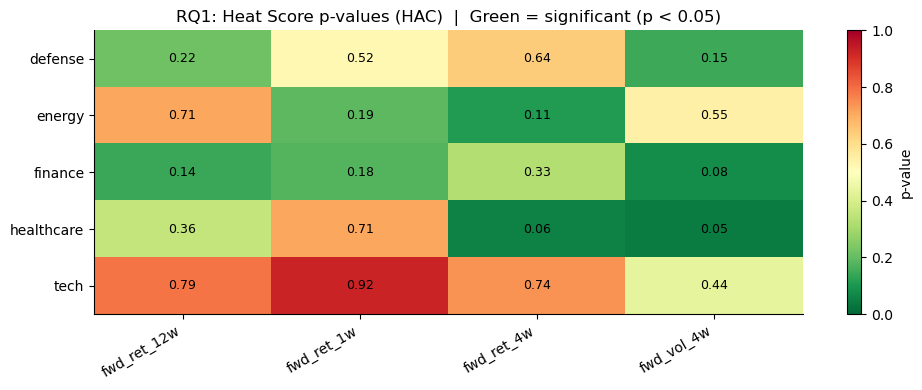

1 of 20 specs significant at p < 0.05


In [8]:
# p-value heatmap
pivot = rq1.pivot(index='sector', columns='outcome', values='p_heat')
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
plt.colorbar(im, ax=ax, label='p-value')
ax.set_title('RQ1: Heat Score p-values (HAC)  |  Green = significant (p < 0.05)')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, str(round(v, 2)), ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print(str((rq1['p_heat'] < 0.05).sum()) + ' of ' + str(len(rq1)) + ' specs significant at p < 0.05')

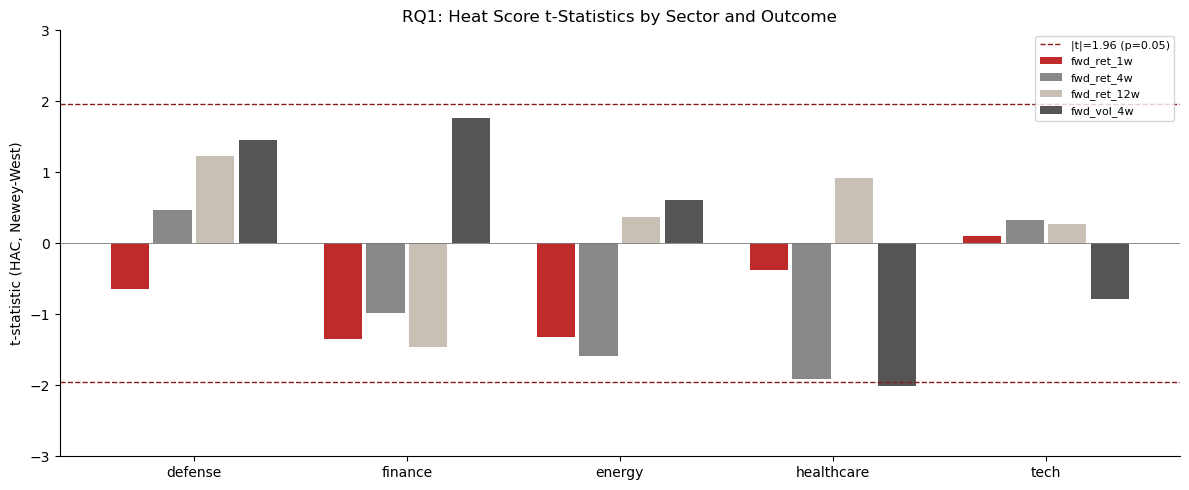

In [9]:
# t-statistic grouped bar chart
sectors5 = rq1['sector'].unique()
outcomes  = rq1['outcome'].unique()
n_sec = len(sectors5)
n_out = len(outcomes)
x = np.arange(n_sec)
width = 0.8 / n_out
colors_t = ['#BF2B2B', '#888888', '#C8C0B4', '#555555']

fig, ax = plt.subplots(figsize=(12, 5))
for i, outcome in enumerate(outcomes):
    sub = rq1[rq1['outcome'] == outcome].set_index('sector')
    t_vals = [sub.loc[s, 't_heat'] if s in sub.index else 0 for s in sectors5]
    offset = (i - n_out/2 + 0.5) * width
    ax.bar(x + offset, t_vals, width=width*0.9,
           label=str(outcome), color=colors_t[i % len(colors_t)])

ax.axhline( 1.96, color='#8B1A1A', linestyle='--', linewidth=1, label='|t|=1.96 (p=0.05)')
ax.axhline(-1.96, color='#8B1A1A', linestyle='--', linewidth=1)
ax.axhline(0, color='#777777', linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(sectors5)
ax.set_ylabel('t-statistic (HAC, Newey-West)')
ax.set_title('RQ1: Heat Score t-Statistics by Sector and Outcome')
ax.set_ylim(-3, 3)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## 5. RQ2 — Sensitivity Analysis
`(rq2_sensitivity.py · run_rq2)`

In [10]:
rq2

,spec,sector,outcome,scope,n,coef,t,p,r2
0,net_buy_count,defense,fwd_ret_20d,full,968,-3.173294e-03,-0.711981,4.764763e-01,0.000476
1,net_buy_count,defense,fwd_ret_20d,first_half,484,-1.192460e-02,-4.160643,3.173526e-05,0.005466
2,net_buy_count,defense,fwd_ret_20d,second_half,484,3.306790e-03,0.903520,3.662499e-01,0.000676
3,net_buy_count,finance,fwd_ret_20d,full,968,2.452660e-03,1.243677,2.136183e-01,0.002357
4,net_buy_count,finance,fwd_ret_20d,first_half,484,4.027917e-03,2.091472,3.648574e-02,0.005688
5,net_buy_count,finance,fwd_ret_20d,second_half,484,-1.371695e-03,-0.375263,7.074647e-01,0.000990
6,net_buy_count,energy,fwd_ret_20d,full,968,3.455670e-03,0.789701,4.297023e-01,0.002212
7,net_buy_count,energy,fwd_ret_20d,first_half,484,1.271902e-02,1.199023,2.305189e-01,0.013796
8,net_buy_count,energy,fwd_ret_20d,second_half,484,-8.503171e-04,-0.305465,7.600120e-01,0.000305
9,net_buy_count,healthcare,fwd_ret_20d,full,968,-2.079256e-03,-1.110833,2.666402e-01,0.003312


In [11]:
if 'p_heat' in rq2.columns and 'sector' in rq2.columns:
    spec_col = next((c for c in ['spec','outcome','specification'] if c in rq2.columns), None)
    if spec_col:
        pivot_rq2 = rq2.pivot_table(index='sector', columns=spec_col, values='p_heat', aggfunc='mean')
        fig, ax = plt.subplots(figsize=(12, 4))
        im = ax.imshow(pivot_rq2.values, cmap='RdYlGn_r', vmin=0, vmax=0.5, aspect='auto')
        ax.set_xticks(range(len(pivot_rq2.columns)))
        ax.set_xticklabels(pivot_rq2.columns, rotation=40, ha='right', fontsize=8)
        ax.set_yticks(range(len(pivot_rq2.index)))
        ax.set_yticklabels(pivot_rq2.index)
        plt.colorbar(im, ax=ax, label='p-value')
        ax.set_title('RQ2: p-values by sector x specification')
        plt.tight_layout()
        plt.show()
print('RQ2 columns:', list(rq2.columns))

RQ2 columns: ['spec', 'sector', 'outcome', 'scope', 'n', 'coef', 't', 'p', 'r2']


## 6. Alpha Estimation
`(alpha_context.py · run_alpha)`

In [12]:
alpha

,model,n,alpha_weekly,alpha_annual,alpha_t,alpha_p,beta_mkt,r2,beta_smb,beta_hml
0,CAPM,152,-0.000626,-0.032034,-0.461929,0.644132,0.053539,0.003448,NaN,NaN
1,FF3,152,-0.000250,-0.012904,-0.181123,0.856271,-0.062258,0.135277,0.158048,-0.413561


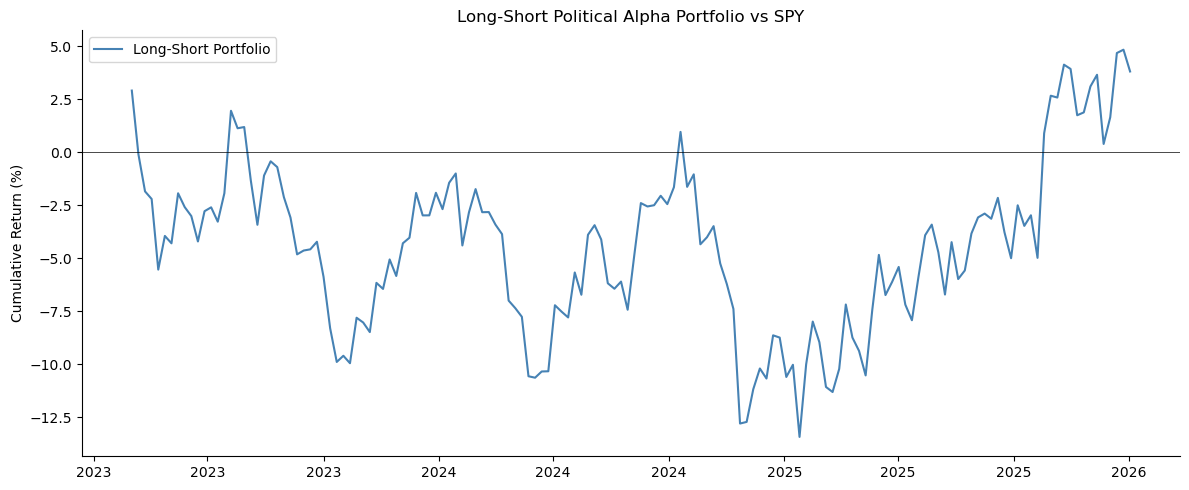

Portfolio cumulative return: 3.8%
Max drawdown: -15.86%


In [13]:
port_series = portfolio['portfolio_return'].dropna()
cum_ret = (1 + port_series).cumprod() - 1

fig, ax = plt.subplots()
ax.plot(cum_ret.index, cum_ret.values * 100,
        label='Long-Short Portfolio', color='steelblue', linewidth=1.5)

if 'SPY' in market.columns:
    spy_weekly = market['SPY'].resample('W-FRI').last().pct_change().dropna()
    spy_weekly = spy_weekly[
        (spy_weekly.index >= cum_ret.index.min()) &
        (spy_weekly.index <= cum_ret.index.max())
    ]
    spy_cum = (1 + spy_weekly).cumprod() - 1
    ax.plot(spy_cum.index, spy_cum.values * 100,
            label='SPY (buy & hold)', color='gray', linestyle='--', alpha=0.8)

ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Cumulative Return (%)')
ax.set_title('Long-Short Political Alpha Portfolio vs SPY')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

final_ret = round(cum_ret.iloc[-1]*100, 2)
dd = ((1+port_series).cumprod() / (1+port_series).cumprod().cummax() - 1).min()
print('Portfolio cumulative return: ' + str(final_ret) + '%')
print('Max drawdown: ' + str(round(dd*100, 2)) + '%')

## 7. Structural Break Analysis

Andrews SupF test + CUSUM. Significant if SupF > 9.10 (5% critical value, k=2).  
`(structural_break.py)`

In [14]:
import statsmodels.api as sm
from structural_break import _chow_f_stat, _SUPF_CRIT, _EVENTS, ROLLING_WINDOW, TRIM

etf_map = {s: v['etf'] for s, v in SECTORS.items()}
weekly_prices = market[[t for t in etf_map.values() if t in market.columns]].resample('W-FRI').last()
weekly_returns = weekly_prices.pct_change()

break_rows = []
rolling_coefs = {}

for sector, ticker in etf_map.items():
    if ticker not in weekly_returns.columns or sector not in heat_wide.columns:
        continue
    df = pd.DataFrame({
        'heat': heat_wide[sector],
        'fwd_ret': weekly_returns[ticker].shift(-1),
        'lag_ret': weekly_returns[ticker].shift(1),
    }).dropna()
    n = len(df)
    print(sector + ': ' + str(n) + ' rows')
    if n < 12:
        continue
    y = df['fwd_ret']
    X = sm.add_constant(df[['heat', 'lag_ret']])
    window = max(8, min(20, n // 2))
    coefs = [(y.index[end-1], sm.OLS(y.iloc[end-window:end], X.iloc[end-window:end]).fit().params.get('heat', np.nan))
             for end in range(window, n+1)]
    rolling_coefs[sector] = pd.Series([c for _,c in coefs], index=[d for d,_ in coefs])
    if n >= 20:
        lo, hi = int(np.ceil(TRIM*n)), int(np.floor((1-TRIM)*n))
        f_by_date = {y.index[k]: _chow_f_stat(y, X, k) for k in range(lo, hi+1)}
        f_by_date = {d: v for d,v in f_by_date.items() if not np.isnan(v)}
        if f_by_date:
            supf = max(f_by_date.values())
            break_date = max(f_by_date, key=f_by_date.get)
        else:
            supf, break_date = np.nan, None
    else:
        supf, break_date = np.nan, None
    break_rows.append({'sector': sector, 'break_date': break_date,
        'supf_stat': round(supf,3) if not np.isnan(supf) else np.nan,
        'supf_significant_5pct': supf > _SUPF_CRIT[0.05] if not np.isnan(supf) else False})

breaks = pd.DataFrame(break_rows)
print('\nSectors analyzed: ' + str(len(breaks)))
display(breaks)

defense: 110 rows
finance: 114 rows
energy: 114 rows
healthcare: 114 rows
tech: 114 rows

Sectors analyzed: 5


,sector,break_date,supf_stat,supf_significant_5pct
0,defense,2025-04-04,1.888,False
1,finance,2025-02-14,0.526,False
2,energy,2025-01-17,2.493,False
3,healthcare,2025-08-08,2.611,False
4,tech,2024-09-20,1.631,False


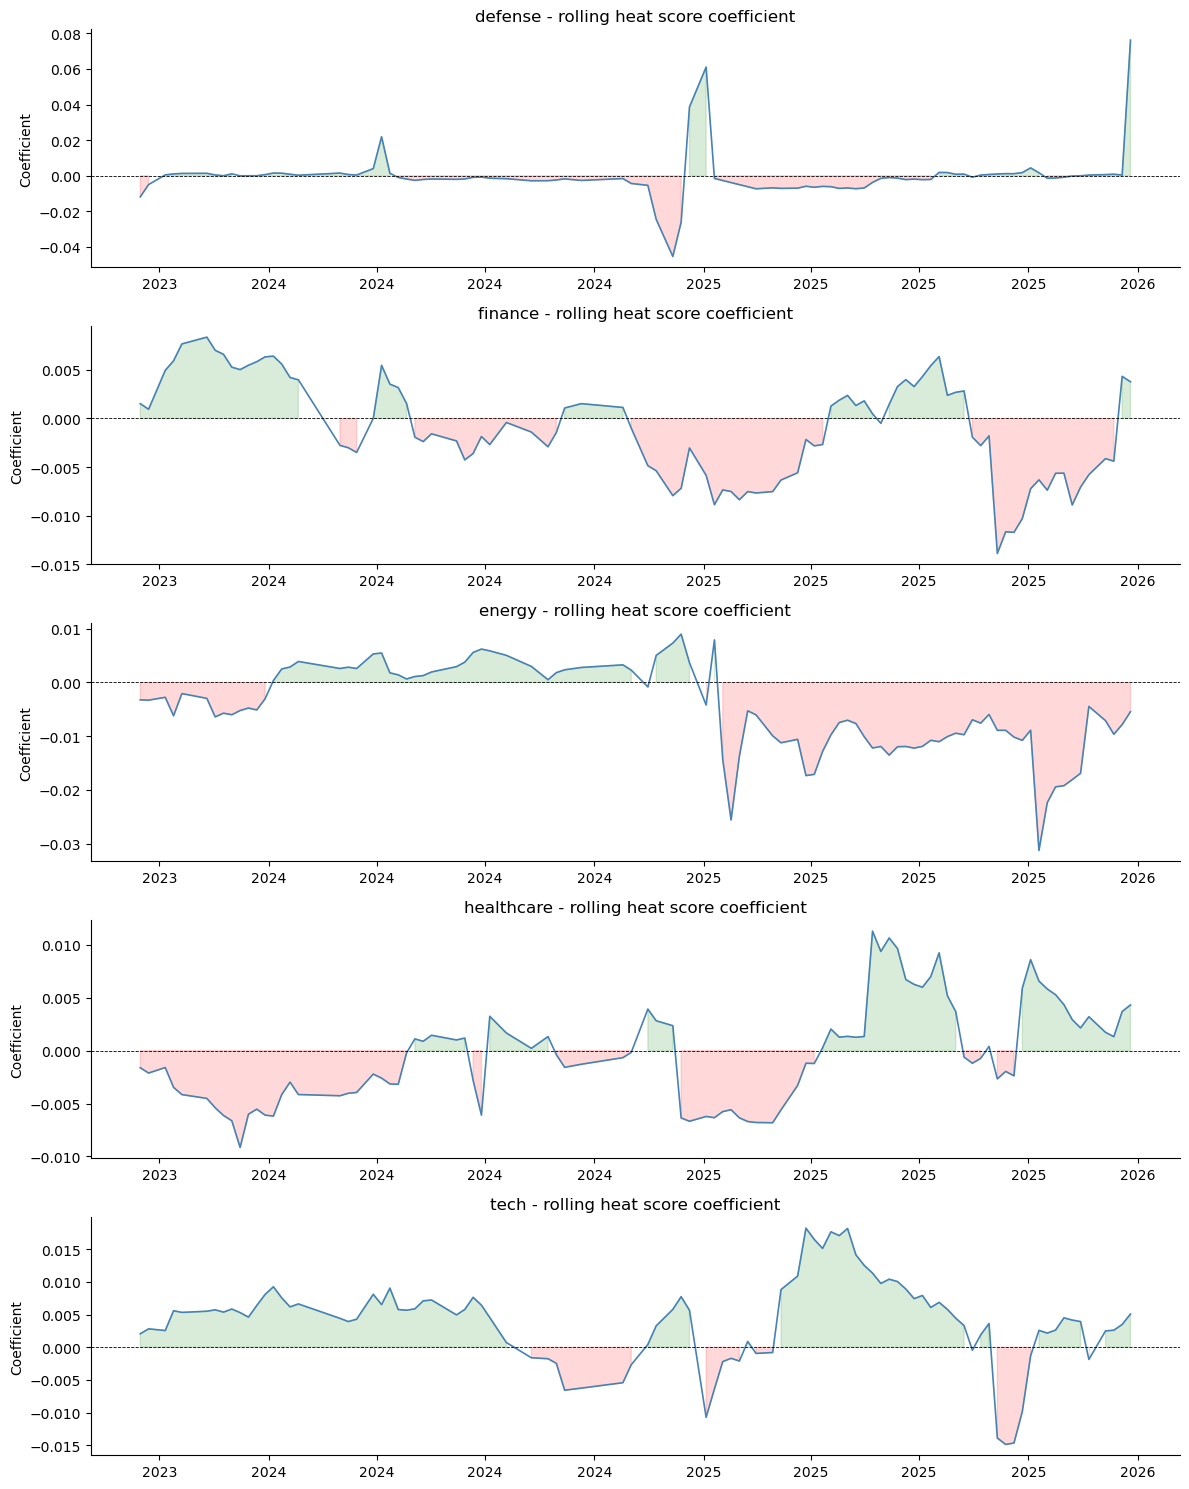

In [15]:
if rolling_coefs:
    n_plots = len(rolling_coefs)
    fig, axes = plt.subplots(n_plots, 1, figsize=(12, 3*n_plots))
    if n_plots == 1:
        axes = [axes]
    for ax, (sector, roll) in zip(axes, rolling_coefs.items()):
        ax.plot(roll.index, roll.values, color='steelblue', linewidth=1.2)
        ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
        ax.fill_between(roll.index, roll.values, 0, where=roll.values>0, alpha=0.15, color='green')
        ax.fill_between(roll.index, roll.values, 0, where=roll.values<0, alpha=0.15, color='red')
        if not breaks.empty:
            row = breaks[breaks['sector']==sector]
            if not row.empty and row['supf_significant_5pct'].values[0]:
                bd = pd.to_datetime(row['break_date'].values[0])
                ax.axvline(bd, color='crimson', linewidth=1.5, label='Break ' + str(bd.date()))
                ax.legend(fontsize=7)
        for label, ds in _EVENTS.items():
            ev = pd.Timestamp(ds)
            if roll.index.min() <= ev <= roll.index.max():
                ax.axvline(ev, color='gray', linewidth=0.8, linestyle=':')
        ax.set_title(sector + ' - rolling heat score coefficient')
        ax.set_ylabel('Coefficient')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    plt.show()
else:
    print('No rolling coefficients computed.')

## 8. Summary

In [16]:
print('Results files:')
for f in sorted(RESULTS_DIR.glob('*.csv')):
    print('  ' + f.name)

Results files:
  alpha_summary.csv
  portfolio_returns.csv
  portfolio_weights.csv
  rq1_inference.csv
  rq2_sensitivity.csv
  rq3_interaction.csv
